In [ ]:
# Fashion Color Analysis: Luxury vs Fast Fashion

This project analyzes color strategies across luxury (Hermès, Loro Piana) and fast fashion (Zara, H&M) brands using Python and clustering techniques.

In [39]:
import os
from PIL import Image
import numpy as np
from sklearn.cluster import KMeans
from collections import Counter
import matplotlib.pyplot as plt

In [40]:
!pip install pillow numpy scikit-learn matplotlib

In [41]:
base_path = "/Users/bengusenaerdem/Downloads/Fashion_Project/Data/Brands"

In [42]:
print(os.getcwd())
print(os.listdir(base_path))

/Users/bengusenaerdem
['Hm_bags', '.DS_Store', 'Hermes_Bags', 'Hermes_Shoes', 'Loro_bags', 'Loro_shoes', 'Zara_shoes', 'Hm_shoes', 'Zara_bags']


In [ ]:
## Method

Images were collected from brand websites and dominant colors were extracted using KMeans clustering.

In [43]:
def get_dominant_color(image_path, k=3, white_threshold=245):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((200, 200))

    img_array = np.array(img)
    h, w, _ = img_array.shape

    
    cropped = img_array[h//3:2*h//3, w//3:2*w//3]
    pixels = cropped.reshape(-1, 3)

   
    non_white_pixels = pixels[
        ~((pixels[:, 0] > white_threshold) &
          (pixels[:, 1] > white_threshold) &
          (pixels[:, 2] > white_threshold))
    ]

    if len(non_white_pixels) < 10:
        non_white_pixels = pixels

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(non_white_pixels)

    colors = kmeans.cluster_centers_
    counts = np.bincount(kmeans.labels_)
    dominant_color = colors[np.argmax(counts)]

    return dominant_color.astype(int)

In [44]:
def color_category(rgb):
    r, g, b = rgb

    if r < 70 and g < 70 and b < 70:
        return "black"
    elif r > 200 and g > 200 and b > 200:
        return "white"
    elif r > 170 and g > 140 and b > 110:
        return "beige"
    elif r > 120 and g > 90 and b < 80:
        return "brown"
    elif r > 150 and g < 100 and b < 100:
        return "red"
    elif b > 120 and b > r and b > g:
        return "blue"
    elif g > 120 and g > r and g > b:
        return "green"
    elif r > 120 and g > 120 and b < 100:
        return "yellow"
    elif abs(r - g) < 20 and abs(g - b) < 20:
        return "gray"
    else:
        return "other"

In [45]:
def color_category(rgb):
    r, g, b = rgb

    
    if r < 70 and g < 70 and b < 70:
        return "black"
    
    
    elif r > 225 and g > 225 and b > 225 and abs(r-g) < 12 and abs(g-b) < 12:
        return "white"
    
   
    elif r > 180 and g > 160 and b > 130:
        return "beige"
    

    elif r > 100 and g > 75 and b < 120:
        return "brown"
    

    elif r > 60 and r < 170 and g < 100 and b < 100:
        return "burgundy"
    
   
    elif r >= 170 and g < 120 and b < 120:
        return "red"
    
   
    elif b > 120 and b > r and b > g:
        return "blue"
    
    
    elif g > 120 and g > r and g > b:
        return "green"
    
    
    elif r > 150 and g > 140 and b < 120:
        return "yellow"
    
 
    elif abs(r - g) < 15 and abs(g - b) < 15:
        return "gray"
    
    else:
        return "other"

In [46]:
test_folder = os.path.join(base_path, "Hermes_Bags")

results = []

for file in os.listdir(test_folder):
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        image_path = os.path.join(test_folder, file)
        dominant = get_dominant_color(image_path)
        category = color_category(dominant)
        results.append(category)
        print(file, dominant, category)

print("\nColor count:")
print(Counter(results))

herbag-messenger-39-bag--084623CKAF-front-wm-1-0-0-800-800_g.jpeg [199 186 175] beige
ancrage-bag--086704CK89-front-wm-1-0-0-800-800_g.jpeg [227 224 216] beige
lindy-ii-mini-bag--085957CK55-front-wm-1-0-0-800-800_g.jpeg [223 220 212] beige
hermes-videpoches-bag--088914CK37-front-wm-1-0-0-800-800_g.jpeg [223 219 211] beige
picotin-lock-micro-bag--084235CK55-front-wm-1-0-0-800-800_g.jpeg [71 20 21] burgundy
bolide-messenger-bag--086958CK18-front-wm-1-0-0-800-800_g.jpeg [133 111 101] brown
horseback-bag--085961CKAA-front-wm-1-0-0-800-800_g.jpeg [27 27 27] black
bolide-messenger-bag--086959CK34-front-wm-1-0-0-800-800_g.jpeg [158  96  67] brown
kelly-depeches-25-pouch--083320CKAD-front-wm-1-0-0-800-800_g.jpeg [222 218 209] beige
lindy-ii-mini-bag--085951CKL4-front-wm-1-0-0-800-800_g.jpeg [227 222 215] beige
plume-mini-bag--086559CK3Q-front-wm-1-0-0-800-800_g.jpeg [225 176 180] beige
arcon-bag--085336CKAG-front-wm-1-0-0-800-800_g.jpeg [104  42  46] burgundy
herbag-zip-31-bag--078971CKCQ-fron

In [ ]:
## Results

Below are the dominant color distributions for each brand.

In [47]:
all_results = {}

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)

    if os.path.isdir(folder_path):
        results = []

        for file in os.listdir(folder_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                image_path = os.path.join(folder_path, file)

                try:
                    dominant = get_dominant_color(image_path)
                    category = color_category(dominant)
                    results.append(category)
                except Exception as e:
                    print(f"Hata: {file} -> {e}")

        all_results[folder] = Counter(results)

for folder, counts in all_results.items():
    print(folder, counts)

Hm_bags Counter({'black': 5, 'beige': 4, 'burgundy': 3, 'brown': 2, 'white': 1})
Hermes_Bags Counter({'beige': 9, 'burgundy': 3, 'brown': 2, 'black': 1})
Hermes_Shoes Counter({'beige': 7, 'brown': 4, 'green': 2, 'black': 2})
Loro_bags Counter({'white': 15})
Loro_shoes Counter({'white': 15})
Zara_shoes Counter({'white': 10, 'brown': 2, 'beige': 1, 'black': 1, 'burgundy': 1})
Hm_shoes Counter({'beige': 5, 'burgundy': 4, 'black': 2, 'brown': 2, 'other': 1, 'white': 1})
Zara_bags Counter({'white': 11, 'other': 2, 'beige': 2, 'brown': 1})


/var/folders/lm/x4gfxcld38569y86ttml5hp80000gn/T/ipykernel_73260/2210740681.py:23: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  kmeans.fit(non_white_pixels)


In [48]:
import pandas as pd

rows = []

for folder, counts in all_results.items():
    for color, count in counts.items():
        rows.append([folder, color, count])

df = pd.DataFrame(rows, columns=["Folder", "Color", "Count"])
print(df)

          Folder     Color  Count
0        Hm_bags     black      5
1        Hm_bags  burgundy      3
2        Hm_bags     beige      4
3        Hm_bags     brown      2
4        Hm_bags     white      1
5    Hermes_Bags     beige      9
6    Hermes_Bags  burgundy      3
7    Hermes_Bags     brown      2
8    Hermes_Bags     black      1
9   Hermes_Shoes     green      2
10  Hermes_Shoes     black      2
11  Hermes_Shoes     brown      4
12  Hermes_Shoes     beige      7
13     Loro_bags     white     15
14    Loro_shoes     white     15
15    Zara_shoes     white     10
16    Zara_shoes     brown      2
17    Zara_shoes     beige      1
18    Zara_shoes     black      1
19    Zara_shoes  burgundy      1
20      Hm_shoes  burgundy      4
21      Hm_shoes     other      1
22      Hm_shoes     beige      5
23      Hm_shoes     black      2
24      Hm_shoes     brown      2
25      Hm_shoes     white      1
26     Zara_bags     white     11
27     Zara_bags     other      2
28     Zara_ba

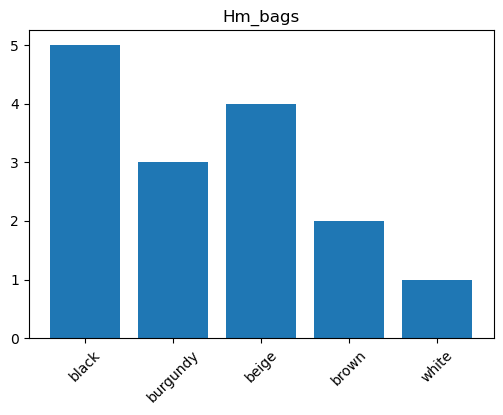

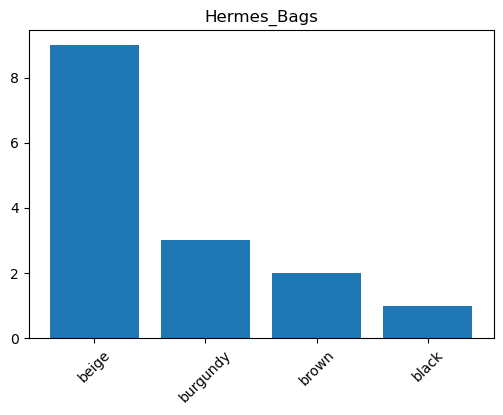

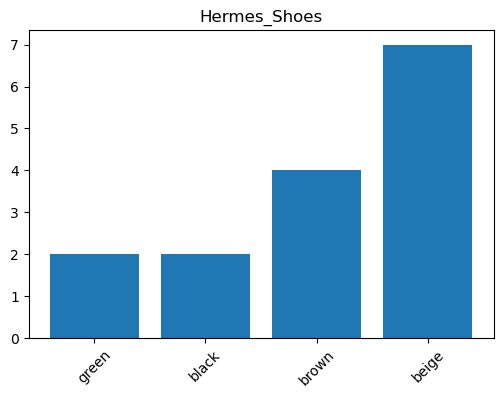

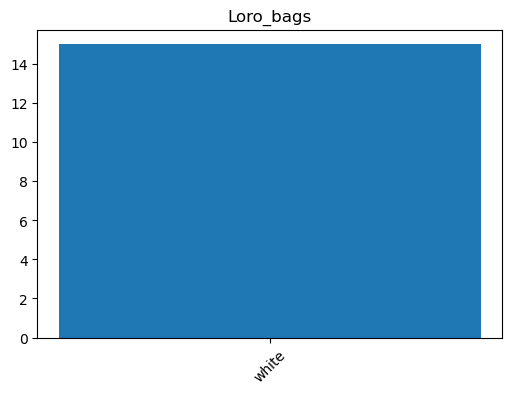

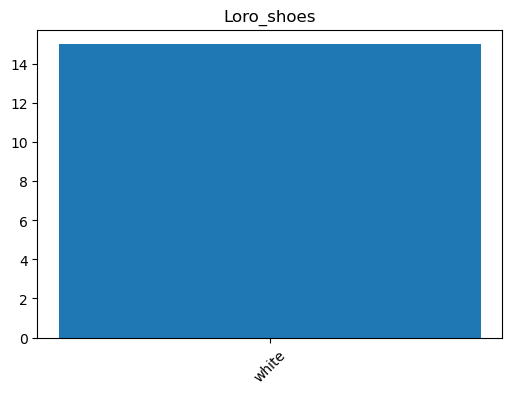

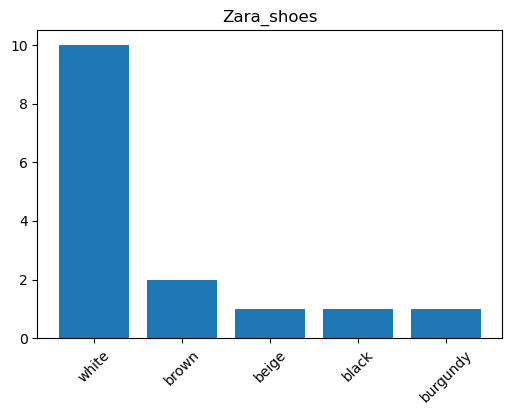

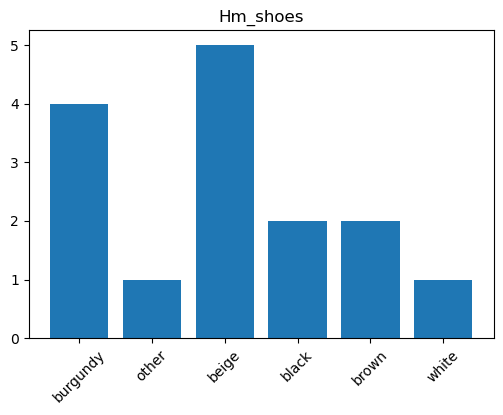

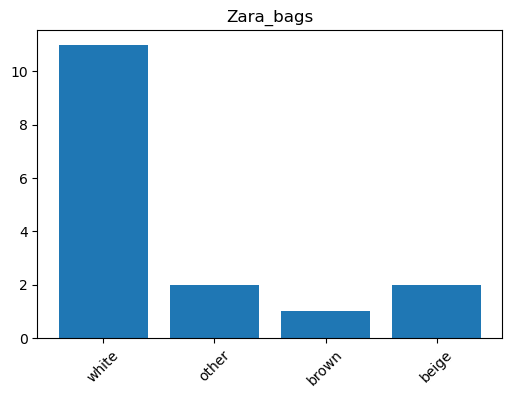

In [49]:
for folder, counts in all_results.items():
    plt.figure(figsize=(6,4))
    plt.bar(counts.keys(), counts.values())
    plt.title(folder)
    plt.xticks(rotation=45)
    plt.show()

In [52]:
def extract_folder_colors(folder_path):
    rgb_list = []

    for file in os.listdir(folder_path):
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            image_path = os.path.join(folder_path, file)

            try:
                dominant = get_dominant_color(image_path)
                rgb_list.append(dominant)
            except Exception as e:
                print(f"Hata: {file} -> {e}")

    return rgb_list

In [53]:
brand_folders = {
    "Hermes": ["Hermes_Bags", "Hermes_Shoes"],
    "Loro Piana": ["Loro_bags", "Loro_shoes"],
    "H&M": ["Hm_bags", "Hm_shoes"],
    "Zara": ["Zara_bags", "Zara_shoes"]
}

brand_rgb_data = {}

for brand, folders in brand_folders.items():
    all_rgbs = []

    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        rgbs = extract_folder_colors(folder_path)
        all_rgbs.extend(rgbs)

    brand_rgb_data[brand] = np.array(all_rgbs)

for brand, rgbs in brand_rgb_data.items():
    print(brand, rgbs.shape)

/var/folders/lm/x4gfxcld38569y86ttml5hp80000gn/T/ipykernel_73260/2210740681.py:23: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  kmeans.fit(non_white_pixels)


Hermes (30, 3)
Loro Piana (30, 3)
H&M (30, 3)
Zara (31, 3)


In [54]:
def get_brand_palette(rgb_array, n_colors=5):
    if len(rgb_array) == 0:
        return None, None

    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    kmeans.fit(rgb_array)

    palette = kmeans.cluster_centers_.astype(int)
    counts = np.bincount(kmeans.labels_)

    
    sorted_idx = np.argsort(counts)[::-1]
    palette = palette[sorted_idx]
    counts = counts[sorted_idx]

    return palette, counts

In [56]:
def plot_palette(palette, title="Color Palette"):
    plt.figure(figsize=(8, 2))

    for i, color in enumerate(palette):
        plt.fill_between([i, i+1], 0, 1, color=color/255)

    plt.xlim(0, len(palette))
    plt.ylim(0, 1)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()
    


Hermes palette RGB values:
[[223 219 211]
 [135  99  72]
 [ 63  32  34]
 [208 185 179]
 [144 158 153]]


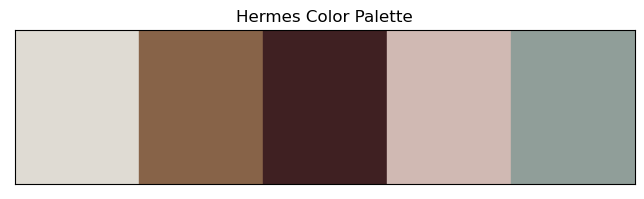


Loro Piana palette RGB values:
[[242 239 234]
 [243 240 235]
 [243 239 233]
 [242 239 235]
 [242 240 235]]


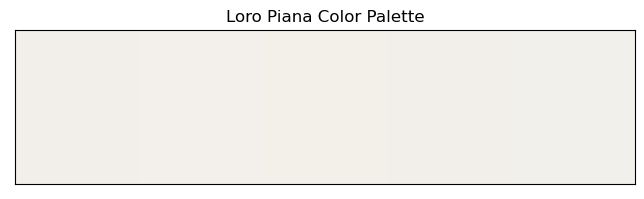


H&M palette RGB values:
[[ 57  34  26]
 [211 196 182]
 [119  78  53]
 [230 226 223]
 [188 147 124]]


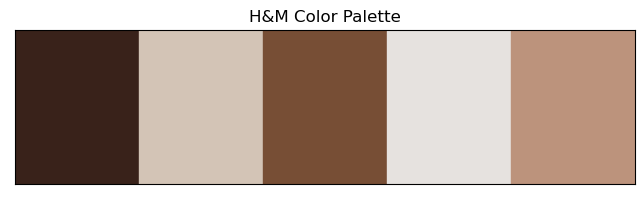


Zara palette RGB values:
[[239 238 235]
 [169 119  97]
 [216 206 207]
 [ 28  54  79]
 [ 88  38  36]]


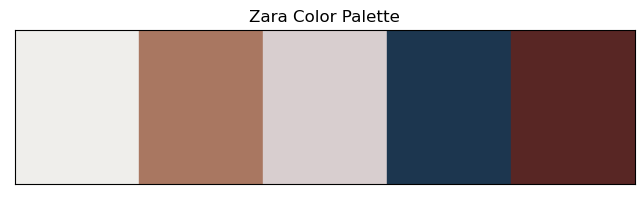

In [57]:
brand_palettes = {}

for brand, rgb_array in brand_rgb_data.items():
    palette, counts = get_brand_palette(rgb_array, n_colors=5)
    brand_palettes[brand] = (palette, counts)

    print(f"\n{brand} palette RGB values:")
    print(palette)

    plot_palette(palette, title=f"{brand} Color Palette")

In [58]:
for brand, (palette, counts) in brand_palettes.items():
    total = counts.sum()
    percentages = (counts / total) * 100

    print(f"\n{brand}")
    for color, pct in zip(palette, percentages):
        print(f"RGB {tuple(color)} -> {pct:.1f}%")


Hermes
RGB (223, 219, 211) -> 36.7%
RGB (135, 99, 72) -> 20.0%
RGB (63, 32, 34) -> 20.0%
RGB (208, 185, 179) -> 16.7%
RGB (144, 158, 153) -> 6.7%

Loro Piana
RGB (242, 239, 234) -> 76.7%
RGB (243, 240, 235) -> 6.7%
RGB (243, 239, 233) -> 6.7%
RGB (242, 239, 235) -> 6.7%
RGB (242, 240, 235) -> 3.3%

H&M
RGB (57, 34, 26) -> 40.0%
RGB (211, 196, 182) -> 23.3%
RGB (119, 78, 53) -> 16.7%
RGB (230, 226, 223) -> 13.3%
RGB (188, 147, 124) -> 6.7%

Zara
RGB (239, 238, 235) -> 71.0%
RGB (169, 119, 97) -> 9.7%
RGB (216, 206, 207) -> 6.5%
RGB (28, 54, 79) -> 6.5%
RGB (88, 38, 36) -> 6.5%


In [ ]:
## Key Insights

- Neutral tones dominate across all brands  
- Luxury brands use more controlled and consistent palettes  
- Fast fashion brands show more variation around a neutral base  
- Shoes tend to have more color diversity than bags  

The key difference lies not in the colors themselves, but in how tightly they are distributed across brands.